# Table 5.9 — Sampling-step comparison (PPDM inference)

Compare **DDPM 2000** (quality reference) vs **DDIM** at 100 / 50 / 20 steps on the ColdFog **test** set (80 images, `plot/test_metadata.json`).

All runs use the same checkpoint: **PPDM physical_v1** (`I75000_E268`).

| Row | Sampler | Steps | η | Role |
|-----|---------|-------|---|------|
| 1 | DDPM | 2000 | — | Quality reference |
| 2 | DDIM | 100 | 0 | Main results table |
| 3 | DDIM | 50 | 0 | Quality–speed trade-off *(optional)* |
| 4 | DDIM | 20 | 0 | Fast inference |

Metrics: `logs/per_image_metrics.json`.  
Time / image: mean inter-sample interval from inference logs — multi-GPU runs use `logs/infer_rank*.log`; single-GPU runs write to `logs/train.log` (see `infer.py`, `setup_worker_log=False`).

In [27]:
from __future__ import annotations

import json
import re
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path("/mnt/newdisk/Documents/linzhanyang/DehazeDDPM")
PLOT_DIR = ROOT / "plot" / "ch5_inference"
TEST_ROOT = ROOT / "experiments/test/physical_v1"
OUT_DIR = PLOT_DIR / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

METADATA_PATH = ROOT / "plot/test_metadata.json"
N_TEST = json.loads(METADATA_PATH.read_text(encoding="utf-8"))["count"]

SAMPLE_TS = re.compile(
    r"(\d{2}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}).*Sample \d+:"
)

In [28]:
def load_summary_metrics(exp_dir: Path) -> dict | None:
    metrics_path = exp_dir / "logs" / "per_image_metrics.json"
    if not metrics_path.is_file():
        return None
    data = json.loads(metrics_path.read_text(encoding="utf-8"))
    if "summary" in data:
        return data["summary"]
    per_image = data.get("per_image", [])
    if not per_image:
        return None
    return {
        "count": len(per_image),
        "psnr_mean": float(np.mean([r["psnr"] for r in per_image])),
        "ssim_mean": float(np.mean([r["ssim"] for r in per_image])),
    }


def _sample_deltas_from_log(log_path: Path) -> list[float]:
    timestamps: list[datetime] = []
    for line in log_path.read_text(encoding="utf-8", errors="replace").splitlines():
        match = SAMPLE_TS.search(line)
        if match:
            timestamps.append(
                datetime.strptime(match.group(1), "%y-%m-%d %H:%M:%S.%f")
            )
    return [
        (t1 - t0).total_seconds() for t0, t1 in zip(timestamps, timestamps[1:])
    ]


def resolve_infer_log_paths(exp_dir: Path) -> list[Path]:
    """Multi-GPU infer.py -> infer_rank*.log; single-GPU -> train.log."""
    log_dir = exp_dir / "logs"
    rank_logs = sorted(log_dir.glob("infer_rank*.log"))
    if rank_logs:
        return rank_logs
    train_log = log_dir / "train.log"
    return [train_log] if train_log.is_file() else []


def parse_infer_time_per_image(exp_dir: Path) -> float | None:
    """Mean seconds between consecutive Sample log lines."""
    deltas: list[float] = []
    for log_path in resolve_infer_log_paths(exp_dir):
        deltas.extend(_sample_deltas_from_log(log_path))
    return float(np.mean(deltas)) if deltas else None


def read_sampler_config(exp_dir: Path) -> dict:
    cfg_path = exp_dir / "logs" / "config_resolved.json"
    if not cfg_path.is_file():
        return {}
    val_cfg = json.loads(cfg_path.read_text(encoding="utf-8")).get(
        "model", {}
    ).get("beta_schedule", {}).get("val", {})
    return val_cfg


def format_eta(eta: float | None) -> str:
    if eta is None:
        return "—"
    if eta == 0:
        return "0"
    return f"{eta:g}"


def format_time(seconds: float | None) -> str:
    if seconds is None:
        return "—"
    if seconds >= 60:
        return f"{seconds / 60:.1f} min"
    return f"{seconds:.1f} s"

In [29]:
CONFIGS = [
    {
        "model": "PPDM",
        "sampler": "DDPM",
        "steps": 2000,
        "eta": None,
        "note": "quality reference",
        "exp_dir": TEST_ROOT / "Dehaze_ColdFog_finetune_test_ddpm_physical_v1_260526_090430",
    },
    {
        "model": "PPDM",
        "sampler": "DDIM",
        "steps": 100,
        "eta": 0.0,
        "note": "main results table",
        "exp_dir": TEST_ROOT / "Dehaze_ColdFog_finetune_test_ddim100_physical_v1_260526_091235",
    },
    {
        "model": "PPDM",
        "sampler": "DDIM",
        "steps": 50,
        "eta": 0.0,
        "note": "quality–speed trade-off (optional)",
        "exp_dir": TEST_ROOT / "Dehaze_ColdFog_finetune_test_ddim50_physical_v1_260527_190938",
    },
    {
        "model": "PPDM",
        "sampler": "DDIM",
        "steps": 20,
        "eta": 0.0,
        "note": "fast inference",
        "exp_dir": TEST_ROOT / "Dehaze_ColdFog_finetune_test_ddim20_physical_v1_260526_090919",
    },
]

In [30]:
rows: list[dict] = []

for cfg in CONFIGS:
    exp_dir = cfg["exp_dir"]
    row = {
        "Model": cfg["model"],
        "Sampler": cfg["sampler"],
        "Steps": cfg["steps"],
        "η": format_eta(cfg["eta"]),
        "Avg PSNR": np.nan,
        "Avg SSIM": np.nan,
        "Time / image": np.nan,
        "_note": cfg["note"],
        "_status": "pending",
    }

    if exp_dir is None:
        row["_status"] = "missing exp_dir"
        rows.append(row)
        print(f"PENDING  DDIM-{cfg['steps']:4d}  — experiment not found yet")
        continue

    if not exp_dir.is_dir():
        row["_status"] = "missing directory"
        rows.append(row)
        print(f"MISSING  DDIM-{cfg['steps']:4d}  {exp_dir}")
        continue

    summary = load_summary_metrics(exp_dir)
    time_s = parse_infer_time_per_image(exp_dir)
    val_cfg = read_sampler_config(exp_dir)

    if summary:
        row["Avg PSNR"] = summary["psnr_mean"]
        row["Avg SSIM"] = summary["ssim_mean"]
        n = summary.get("count", N_TEST)
    else:
        n = 0

    if time_s is not None:
        row["Time / image"] = time_s

    cfg_sampler = val_cfg.get("sampler", "ddpm")
    cfg_steps = val_cfg.get("sample_steps", val_cfg.get("n_timestep"))
    row["_status"] = "ok" if summary and n >= N_TEST else "incomplete"
    rows.append(row)

    status = row["_status"].upper()
    psnr_str = f"{row['Avg PSNR']:.2f}" if not np.isnan(row["Avg PSNR"]) else "—"
    print(
        f"{status:10s}  {cfg['sampler']:4s} {cfg['steps']:4d}  "
        f"n={n:2d}  PSNR={psnr_str}  time={format_time(time_s)}  "
        f"cfg={cfg_sampler}/{cfg_steps}  {exp_dir.name}"
    )

df_raw = pd.DataFrame(rows)
display_cols = ["Model", "Sampler", "Steps", "η", "Avg PSNR", "Avg SSIM", "Time / image"]
df_raw

OK          DDPM 2000  n=80  PSNR=21.02  time=2.9 min  cfg=ddpm/2000  Dehaze_ColdFog_finetune_test_ddpm_physical_v1_260526_090430
OK          DDIM  100  n=80  PSNR=21.52  time=9.3 s  cfg=ddim/100  Dehaze_ColdFog_finetune_test_ddim100_physical_v1_260526_091235
OK          DDIM   50  n=80  PSNR=20.97  time=4.9 s  cfg=ddim/50  Dehaze_ColdFog_finetune_test_ddim50_physical_v1_260527_190938
OK          DDIM   20  n=80  PSNR=19.90  time=2.4 s  cfg=ddim/20  Dehaze_ColdFog_finetune_test_ddim20_physical_v1_260526_090919


,Model,Sampler,Steps,η,Avg PSNR,Avg SSIM,Time / image,_note,_status
0,PPDM,DDPM,2000,—,21.016941,0.901648,176.497205,quality reference,ok
1,PPDM,DDIM,100,0,21.516487,0.843347,9.337962,main results table,ok
2,PPDM,DDIM,50,0,20.973800,0.800570,4.938127,quality–speed trade-off (optional),ok
3,PPDM,DDIM,20,0,19.899390,0.734815,2.365679,fast inference,ok


In [31]:
def format_table(df: pd.DataFrame) -> pd.DataFrame:
    out = df[display_cols].copy()
    out["Avg PSNR"] = out["Avg PSNR"].apply(
        lambda x: "—" if pd.isna(x) else f"{float(x):.2f}"
    )
    out["Avg SSIM"] = out["Avg SSIM"].apply(
        lambda x: "—" if pd.isna(x) else f"{float(x):.3f}"
    )
    out["Time / image"] = out["Time / image"].apply(
        lambda x: "—" if pd.isna(x) else format_time(float(x))
    )
    return out


table_5_9 = format_table(df_raw)
print(f"Table 5.9 — PPDM sampling-step comparison (n={N_TEST} test images)\n")
display(table_5_9)

print("\nRow notes:")
for cfg, row in zip(CONFIGS, rows):
    print(f"  {cfg['sampler']} {cfg['steps']:4d}: {row['_note']}")

Table 5.9 — PPDM sampling-step comparison (n=80 test images)



,Model,Sampler,Steps,η,Avg PSNR,Avg SSIM,Time / image
0,PPDM,DDPM,2000,—,21.02,0.902,2.9 min
1,PPDM,DDIM,100,0,21.52,0.843,9.3 s
2,PPDM,DDIM,50,0,20.97,0.801,4.9 s
3,PPDM,DDIM,20,0,19.90,0.735,2.4 s



Row notes:
  DDPM 2000: quality reference
  DDIM  100: main results table
  DDIM   50: quality–speed trade-off (optional)
  DDIM   20: fast inference


## Qualitative comparison — sampler × steps

3×6 grid: **Light / Medium / Heavy** rows × **Input, DDPM 2000, DDIM 100, DDIM 50, DDIM 20, Ground truth**.

| Column | Source |
|--------|--------|
| Input | `0_{idx}_lr.png` (hazy network input, shared across samplers) |
| DDPM 2000 / DDIM *N* | `{CONFIGS[i].exp_dir}/results/0_{idx}_out.png` |
| Ground truth | `gt_test` resized to input size |

**Index:** 1-based (`plot/test_metadata.json`). Edit `FOG_ROW_CASES` after visual review.

In [32]:
import matplotlib.pyplot as plt
from PIL import Image

TEXTWIDTH_IN = 5.768

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

INFER_SAVE_STEP = 0


def load_metadata(path: Path) -> tuple[dict, dict[int, dict]]:
    meta = json.loads(path.read_text(encoding="utf-8"))
    by_index = {s["index"]: s for s in meta["samples"]}
    return meta, by_index


def load_rgb(path: Path) -> np.ndarray:
    return np.asarray(Image.open(path).convert("RGB"))


def load_gt_matched_to_lr(gt_path: Path, lr_hw: tuple[int, int]) -> np.ndarray:
    h, w = lr_hw
    im = Image.open(gt_path).convert("RGB").resize((w, h), Image.LANCZOS)
    return np.asarray(im)


def infer_out_path(exp_dir: Path, idx: int, infer_step: int = INFER_SAVE_STEP) -> Path:
    return exp_dir / "results" / f"{infer_step}_{idx}_out.png"


def infer_lr_path(exp_dir: Path, idx: int, infer_step: int = INFER_SAVE_STEP) -> Path:
    return exp_dir / "results" / f"{infer_step}_{idx}_lr.png"


def sampler_col_title(cfg: dict) -> str:
    if cfg["sampler"] == "DDPM":
        return f"DDPM\n{cfg['steps']}"
    return f"DDIM\n{cfg['steps']}"


meta, index_to_sample = load_metadata(METADATA_PATH)
GT_ROOT = Path(meta["dataroothq"])
REF_EXP_DIR = CONFIGS[0]["exp_dir"]

SAMPLER_KEYS = [f"out_{i}" for i in range(len(CONFIGS))]
PANEL_SPECS = [("input", "Input")] + [
    (f"out_{i}", sampler_col_title(cfg)) for i, cfg in enumerate(CONFIGS)
] + [("gt", "Ground truth")]
COL_TITLES = [title for _, title in PANEL_SPECS]

print(f"GT root: {GT_ROOT}")
print(f"Reference results (input): {REF_EXP_DIR / 'results'}")

GT root: /mnt/newdisk/Documents/linzhanyang/data/dehazeddpm_test/gt_test
Reference results (input): /mnt/newdisk/Documents/linzhanyang/DehazeDDPM/experiments/test/physical_v1/Dehaze_ColdFog_finetune_test_ddpm_physical_v1_260526_090430/results


In [37]:
# One representative scene per fog level. Edit after visual review.
FOG_ROW_CASES = [
    {"row": "Light", "fog_level": "low", "index": 14},
    {"row": "Medium", "fog_level": "medium", "index": 8},
    {"row": "Heavy", "fog_level": "heavy", "index": 23},
]


def collect_row_panels(case: dict) -> dict[str, np.ndarray]:
    idx = case["index"]
    sample = index_to_sample[idx]
    lr_path = infer_lr_path(REF_EXP_DIR, idx)
    gt_path = GT_ROOT / sample["filename"]
    fog = load_rgb(lr_path)
    gt = load_gt_matched_to_lr(gt_path, fog.shape[:2])
    panels = {"input": fog, "gt": gt}
    for i, cfg in enumerate(CONFIGS):
        panels[f"out_{i}"] = load_rgb(infer_out_path(cfg["exp_dir"], idx))
    return panels


def verify_row_case(case: dict) -> None:
    idx = case["index"]
    sample = index_to_sample[idx]
    paths = {"input": infer_lr_path(REF_EXP_DIR, idx), "gt": GT_ROOT / sample["filename"]}
    for i, cfg in enumerate(CONFIGS):
        paths[f"out_{i}"] = infer_out_path(cfg["exp_dir"], idx)
    missing = [k for k, p in paths.items() if not p.is_file()]
    status = "OK" if not missing else f"MISSING {missing}"
    print(
        f"[{case['row']}] idx={idx:2d} meta_fog={sample['fog_level']:6s} "
        f"{sample['filename'][:36]:36s} — {status}"
    )


for case in FOG_ROW_CASES:
    verify_row_case(case)

[Light] idx=14 meta_fog=low    ggl_20260202_0056_low.jpg            — OK
[Medium] idx= 8 meta_fog=medium sdm_20260210_0250_medium.png         — OK
[Heavy] idx=23 meta_fog=heavy  ggl_20260202_0026_heavy.jpg          — OK


In [38]:
def load_per_image_metrics(exp_dir: Path) -> dict[int, dict]:
    data = json.loads((exp_dir / "logs" / "per_image_metrics.json").read_text(encoding="utf-8"))
    records = data.get("per_image", data)
    return {r["index"]: r for r in records}


metrics_ddim100 = load_per_image_metrics(CONFIGS[1]["exp_dir"])
TOP_K_CANDIDATES = 5
FOG_LEVEL_GROUPS = [("Light", "low"), ("Medium", "medium"), ("Heavy", "heavy")]


def rank_by_psnr(fog_level: str, top_k: int = TOP_K_CANDIDATES) -> list[dict]:
    rows = []
    for sample in meta["samples"]:
        if sample["fog_level"] != fog_level:
            continue
        idx = sample["index"]
        m = metrics_ddim100[idx]
        rows.append({"index": idx, "psnr": m["psnr"], "ssim": m["ssim"], "filename": sample["filename"]})
    rows.sort(key=lambda r: r["psnr"], reverse=True)
    return rows[:top_k]


for label, level in FOG_LEVEL_GROUPS:
    ranked = rank_by_psnr(level)
    idx_list = [r["index"] for r in ranked]
    print(f"{label} ({level}) — top-{TOP_K_CANDIDATES} by DDIM-100 PSNR: {idx_list}")
    for r in ranked:
        print(f"  idx={r['index']:2d}  PSNR={r['psnr']:.2f}  SSIM={r['ssim']:.3f}  {r['filename']}")
    print()

Light (low) — top-5 by DDIM-100 PSNR: [54, 46, 60, 2, 29]
  idx=54  PSNR=31.04  SSIM=0.985  ggl_20260202_0107_low.jpg
  idx=46  PSNR=30.62  SSIM=0.968  sdm_20260204_0229_low.jpg
  idx=60  PSNR=30.34  SSIM=0.985  sdm_20260204_0199_low.jpg
  idx= 2  PSNR=29.83  SSIM=0.973  sdm_20260204_0213_low.jpg
  idx=29  PSNR=29.74  SSIM=0.937  sd_20260218_0368_low.jpg

Medium (medium) — top-5 by DDIM-100 PSNR: [51, 42, 67, 6, 78]
  idx=51  PSNR=27.32  SSIM=0.972  sd_20260218_0350_medium.jpg
  idx=42  PSNR=26.62  SSIM=0.942  ggl_20260202_0074_medium.jpg
  idx=67  PSNR=26.16  SSIM=0.865  sdm_20260204_0184_medium.jpg
  idx= 6  PSNR=26.09  SSIM=0.933  ggl_20260204_0154_medium.jpg
  idx=78  PSNR=25.19  SSIM=0.950  sd_20260213_0310_medium.jpg

Heavy (heavy) — top-5 by DDIM-100 PSNR: [21, 66, 68, 11, 55]
  idx=21  PSNR=25.56  SSIM=0.885  sd_20260218_0365_heavy.jpg
  idx=66  PSNR=24.37  SSIM=0.941  ggl_20260202_0072_heavy.jpg
  idx=68  PSNR=23.41  SSIM=0.862  sdm_20260212_0275_heavy.jpg
  idx=11  PSNR=22.59

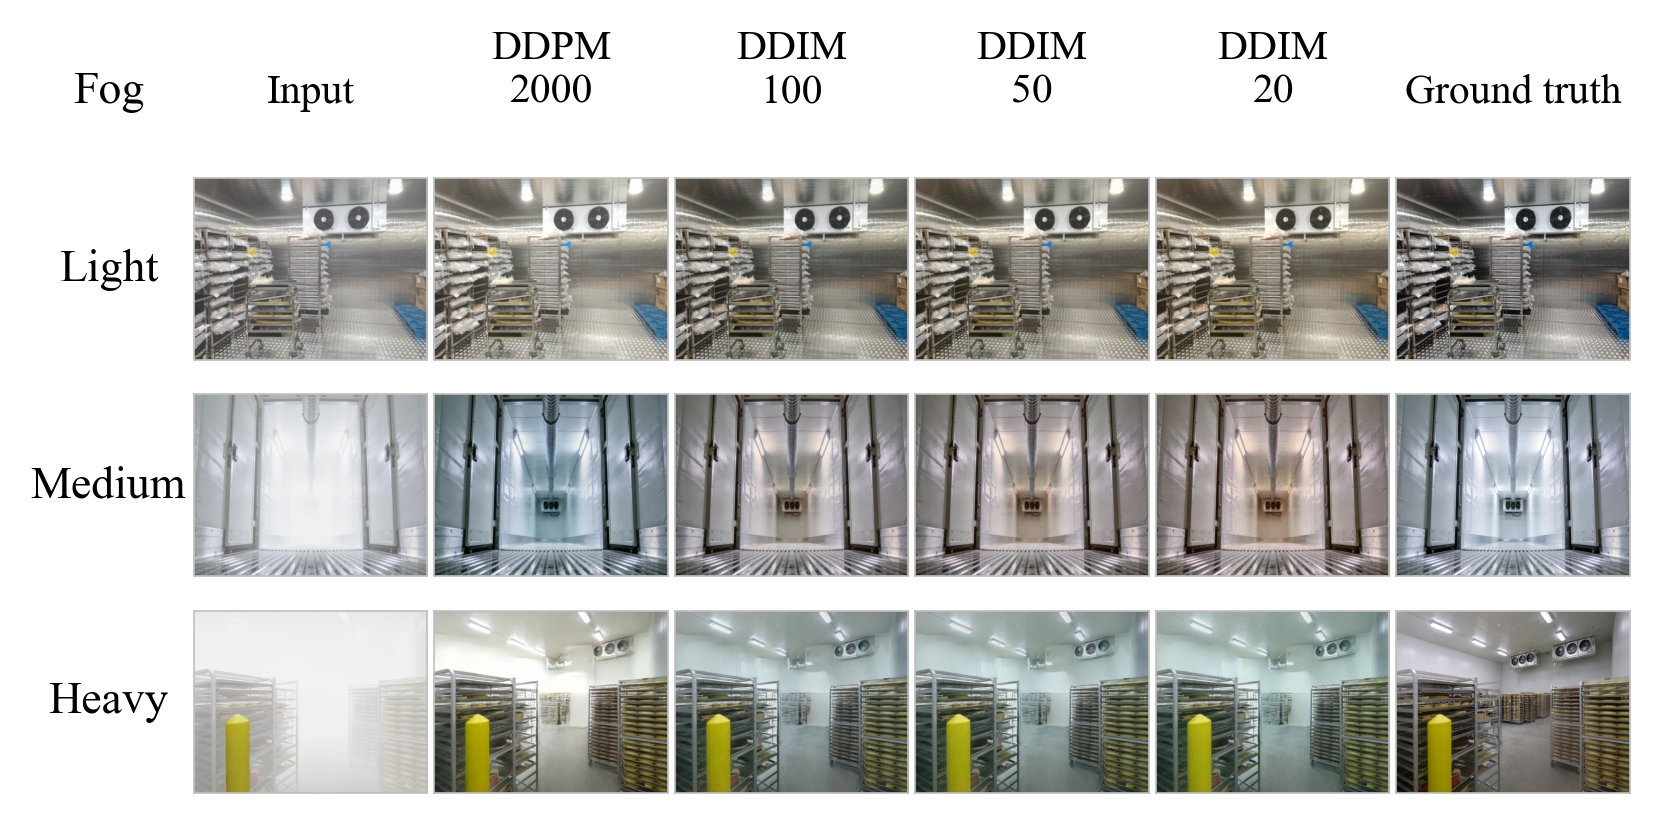

In [39]:
ROW_COL_WIDTH = 0.55
IMG_COL_WIDTH = 0.82


def show_sampler_step_grid(
    cases: list[dict],
    *,
    save_path: Path | None = None,
) -> plt.Figure:
    n = len(cases)
    first_idx = cases[0]["index"]
    fog0 = load_rgb(infer_lr_path(REF_EXP_DIR, first_idx))
    img_aspect = fog0.shape[0] / fog0.shape[1]

    fig_width = ROW_COL_WIDTH + len(COL_TITLES) * IMG_COL_WIDTH
    row_height = IMG_COL_WIDTH * img_aspect
    fig_height = 0.24 + n * row_height + 0.28

    fig = plt.figure(figsize=(fig_width, fig_height))
    width_ratios = [ROW_COL_WIDTH / IMG_COL_WIDTH] + [1.0] * len(COL_TITLES)
    gs = fig.add_gridspec(
        n + 1,
        len(COL_TITLES) + 1,
        height_ratios=[0.18] + [1.0] * n,
        width_ratios=width_ratios,
        wspace=0.03,
        hspace=0.06,
        left=0.02,
        right=0.995,
        top=0.96,
        bottom=0.02,
    )

    ax_row_hdr = fig.add_subplot(gs[0, 0])
    ax_row_hdr.set_title("Fog", fontsize=11, pad=4)
    ax_row_hdr.axis("off")
    for c, title in enumerate(COL_TITLES, start=1):
        ax_title = fig.add_subplot(gs[0, c])
        ax_title.set_title(title, fontsize=10, pad=4)
        ax_title.axis("off")

    for r, case in enumerate(cases):
        panels = collect_row_panels(case)
        ax_row = fig.add_subplot(gs[r + 1, 0])
        ax_row.axis("off")
        ax_row.text(0.5, 0.5, case["row"], ha="center", va="center", fontsize=11)

        for c, (col_key, _) in enumerate(PANEL_SPECS, start=1):
            ax = fig.add_subplot(gs[r + 1, c])
            ax.imshow(panels[col_key])
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_linewidth(0.4)
                spine.set_color("0.75")

    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight", pad_inches=0.02)
        print(f"Saved: {save_path}")

    return fig


fig = show_sampler_step_grid(FOG_ROW_CASES)
plt.show()

In [40]:
composite_path = OUT_DIR / "sampling_step_fog_level_comparison.png"
show_sampler_step_grid(FOG_ROW_CASES, save_path=composite_path)

# Optional PDF for thesis
# show_sampler_step_grid(FOG_ROW_CASES, save_path=OUT_DIR / "sampling_step_fog_level_comparison.pdf")
plt.close("all")

Saved: /mnt/newdisk/Documents/linzhanyang/DehazeDDPM/plot/ch5_inference/output/sampling_step_fog_level_comparison.png
